In [1]:
from openpiv import tools, pyprocess, validation, filters, scaling

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import matplotlib.pyplot as plt
import openpiv.tools

import imageio
import pathlib
import cmcrameri.cm as cm

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

# Particle Image Velocimetry
#### Kjersti Stangeland, Spring 2026
**Analyzing**:
* f = 1.4 Hz
* A = 0.2 V
* D = 0.2 m
* H = 0.15 m

Run 1 out of 3

In [2]:
# Load images
frame_a  = tools.imread('/Users/kjesta/Desktop/PIV/f14a02/R1/image_p1220.bmp')
frame_b  = tools.imread('/Users/kjesta/Desktop/PIV/f14a02/R1/image_p1221.bmp')

In [3]:
fps = 125
dt = 1/fps
print(f'Time between frames: {dt:.2f} seconds')

Time between frames: 0.01 seconds


In [4]:
# Frame number
im1 = 1220
im2 = 1221

# The timestamp of each frame
# Adds 10 seconds to account for the initial delay before the first frame is captured
t1 = im1*dt + 10
t2 = im2*dt + 10

print(f'Time of frame A: {t1:.2f} seconds')
print(f'Time of frame B: {t2:.2f} seconds')

Time of frame A: 19.76 seconds
Time of frame B: 19.77 seconds


Text(0.5, 0.98, 'Raw image frames ($\\Delta t = 0.01$ s)')

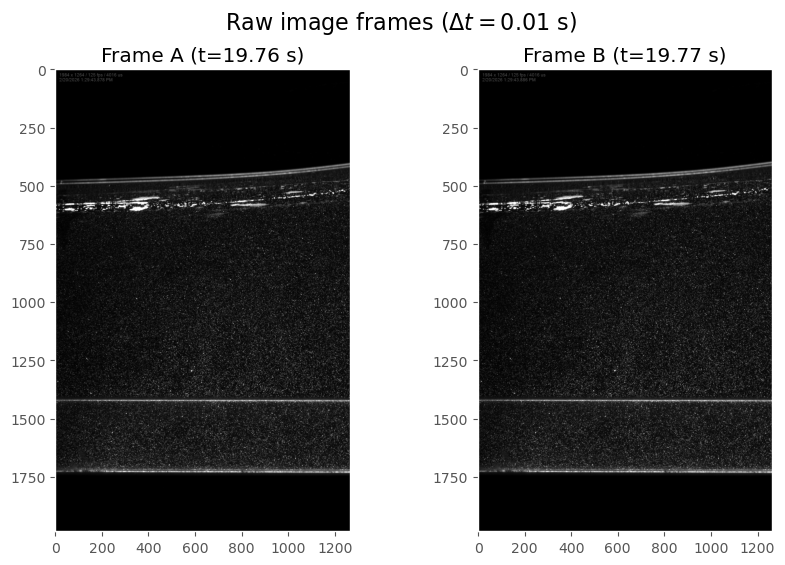

In [5]:
fig, ax =plt.subplots(1,2, figsize=(10,6))
ax[0].imshow(frame_a, cmap='gray')
ax[0].set_title(f'Frame A (t={t1:.2f} s)')

ax[1].imshow(frame_b, cmap='gray')
ax[1].set_title(f'Frame B (t={t2:.2f} s)')

ax[0].grid()
ax[1].grid()

fig.suptitle(rf'Raw image frames ($\Delta t = {dt:.2f}$ s)', fontsize=16)

Text(0.5, 0.9, 'Raw, zoomed in, frames')

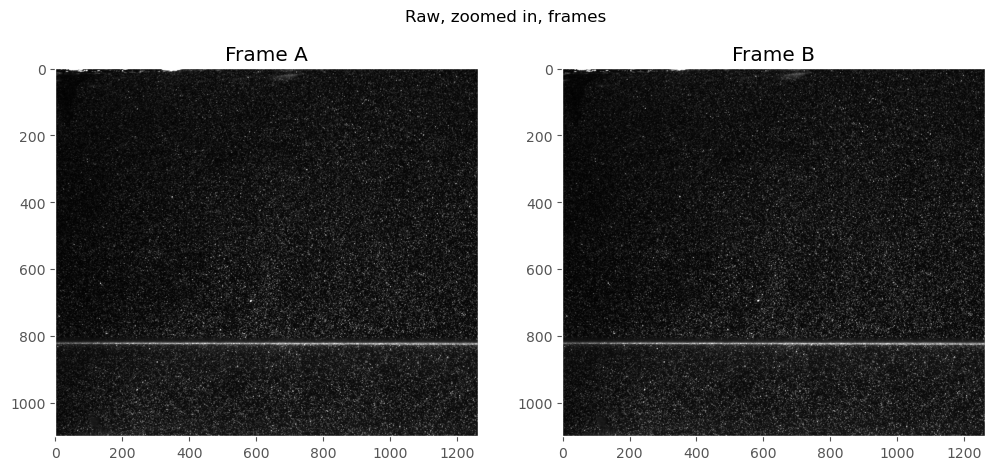

In [6]:
# Zoom in on area of interest
# Ignoring the surface and the bottom of the frame
frame_a = frame_a[600:1700, :]
frame_b = frame_b[600:1700, :]

fig, ax =plt.subplots(1,2, figsize=(12,6))
ax[0].imshow(frame_a, cmap='gray')
ax[0].set_title('Frame A')
ax[0].grid()
ax[1].imshow(frame_b, cmap='gray')
ax[1].set_title('Frame B')
ax[1].grid()
fig.suptitle('Raw, zoomed in, frames', y=0.9)

In [7]:
print(f'Frame A shape: {frame_a.shape}')
print(f'Frame B shape: {frame_b.shape}')

Frame A shape: (1100, 1264)
Frame B shape: (1100, 1264)


In [8]:
window_size = 24
overlap = 16
search_area_size = 64

In [9]:
# Run PIV analysis
u, v, sig2noise = openpiv.pyprocess.extended_search_area_piv(
    frame_a, frame_b, 
    window_size=window_size, 
    overlap=overlap, 
    dt=dt, 
    search_area_size=search_area_size
)

`sig2noise` is a mask indicating which vectors have a minimum amount of S2N. The larger the S2N, the better.

(array([  8.,   0., 105., 213., 176.,  58.,   8.,   2.,   1.,   1.]),
 array([ 0.        ,  2.06662156,  4.13324312,  6.19986469,  8.26648625,
        10.33310781, 12.39972937, 14.46635094, 16.5329725 , 18.59959406,
        20.66621562]),
 <BarContainer object of 10 artists>)

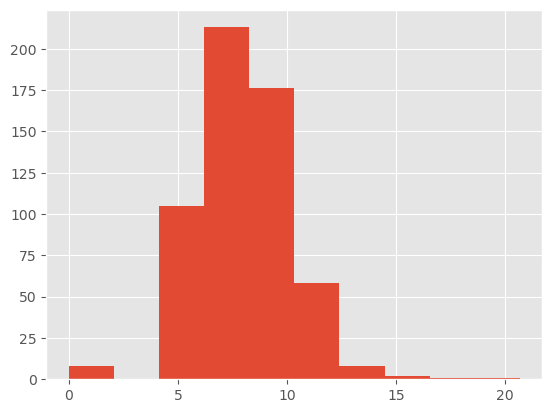

In [10]:
plt.hist(sig2noise.flatten())

In [11]:
x, y = pyprocess.get_coordinates(image_size=frame_a.shape, search_area_size=64, overlap=16)
u, v, mask = validation.sig2noise_val(u, v, sig2noise, threshold = 1.3)

Replace vectors using the mask, marking vectors with low S2N with NaN, and replace with local mean.

In [12]:
u, v = filters.replace_outliers(u, v, method='localmean', max_iter=10, kernel_size=2)

In [13]:
# Scale the coordinates and velocity vectors to physical units (e.g., mm/s)
# SCALING IS WRONG, NEED TO CHECK THE SCALING FACTOR
x, y, u, v = scaling.uniform(x, y, u, v, scaling_factor = 96.52)

In [14]:
tools.save(x, y, u, v, mask, 'test.txt' )

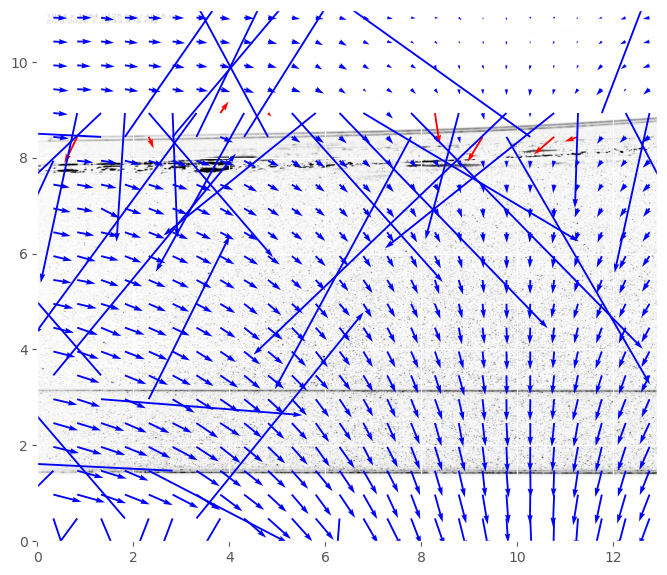

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [15]:
fig, ax = plt.subplots(figsize=(8,8))
tools.display_vector_field(
    pathlib.Path('test.txt'),
    ax=ax, scaling_factor=96.52,
    scale=100, # scale defines here the arrow length
    width=0.003, # width is the thickness of the arrow
    on_img=True, # overlay on the image,
    image_name= str(pathlib.Path('/Users/kjesta/Desktop/PIV/f14a02/R1/image_p1220.bmp')))

In [16]:
curl_u = np.gradient(u, axis=0) # du/dz
curl_w = np.gradient(v, axis=1) # dw/dx
curl = curl_w - curl_u

In [17]:
grad_u = np.gradient(u, axis=1) # du/dx
grad_w = np.gradient(v, axis=0) # dw/dz

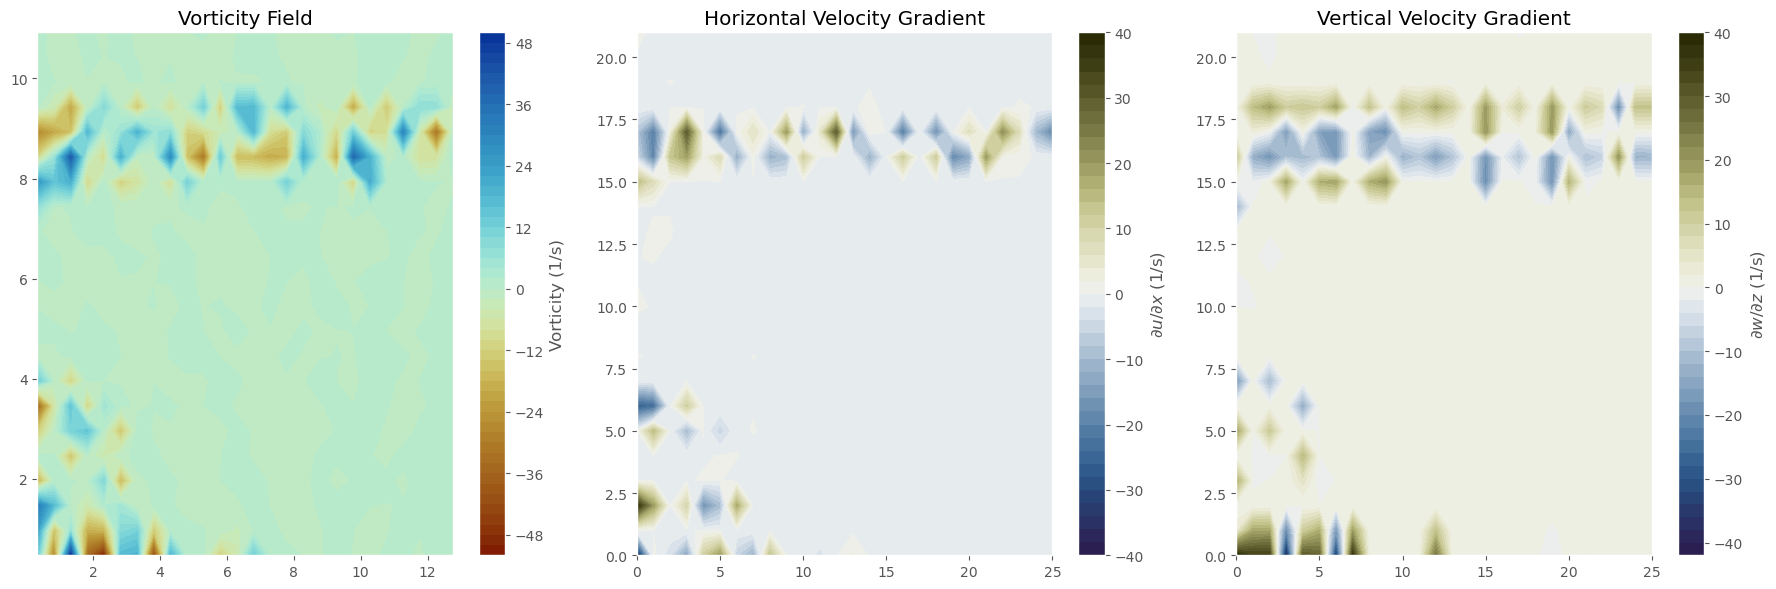

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(18,6))
im = ax[0].contourf(x, y, curl, levels=50, cmap=cm.roma)
cbar = plt.colorbar(im, ax=ax[0], label='Vorticity (1/s)')
ax[0].set_title('Vorticity Field')

im = ax[1].contourf(grad_u, cmap=cm.broc, levels=50)
cbar = plt.colorbar(im, ax=ax[1], label=r'$\partial u / \partial x$ (1/s)')
ax[1].set_title('Horizontal Velocity Gradient')

im = ax[2].contourf(grad_w, cmap=cm.broc, levels=50)
cbar = plt.colorbar(im, ax=ax[2], label=r'$\partial w / \partial z$ (1/s)')
ax[2].set_title('Vertical Velocity Gradient')

plt.tight_layout()

* Må få riktig mapping fra piksel til cm
* Tallene nå er ikke til å stole på, men tror kanskje det generelle inntrykket er
* Vil trekke en linje over platene og finne verdiene for vertikal hastighet over platen, samt gradienten